In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

In [2]:
llama = pd.read_csv('gsm8k/llama2-7b_gsm8k.csv')

In [3]:
mistral = pd.read_csv('gsm8k/mistral-7b_gsm8k.csv')


In [4]:
deepseek = pd.read_csv('gsm8k/deepseek-r1_gsm8k.csv')


In [5]:
models_name = ['llama', 'mistral', 'deepseek']
models = [llama, mistral, deepseek]
# Afficher les résultats pour chaque modèle
for model, model_df in zip(models_name, models):
    print(f"### Résultats pour le modèle {model} ###")
    result_df = model_df.copy()
    #supprimer les lignes avec des réponses None
    result_df = result_df[result_df['response_extracted'].notna()]
    print(f"✅ {len(result_df)} réponses valides sur 500 questions")

    # Cast en string pour éviter des soucis de types
    result_df['true_answer_extracted'] = result_df['true_answer_extracted'].astype(float)
    result_df['response_extracted'] = result_df['response_extracted'].astype(float)

    # Count matches using boolean comparison
    cpt = (result_df['response_extracted'] == result_df['true_answer_extracted']).sum()

    print(f"✅ {cpt} réponses correctes sur {len(result_df)} questions")
    print(f"✅ Taux de réussite : {cpt/len(result_df)*100:.2f}%")

### Résultats pour le modèle llama ###
✅ 435 réponses valides sur 500 questions
✅ 25 réponses correctes sur 435 questions
✅ Taux de réussite : 5.75%
### Résultats pour le modèle mistral ###
✅ 443 réponses valides sur 500 questions
✅ 220 réponses correctes sur 443 questions
✅ Taux de réussite : 49.66%
### Résultats pour le modèle deepseek ###
✅ 258 réponses valides sur 500 questions
✅ 238 réponses correctes sur 258 questions
✅ Taux de réussite : 92.25%


In [6]:
def metrics(dataframe):
    # Create a copy of the dataframe to avoid modifying the original one
    df = dataframe.copy()
    # Convert to numeric and identify NaN values
    df['response_extracted'] = pd.to_numeric(df['response_extracted'], errors='coerce')

    # Drop rows with NaN values in the response column
    df_clean = df#.dropna(subset=['response_extracted']).copy()

    # Create a binary correctness column (1 if match, 0 if not)
    df_clean['is_correct'] = (df_clean['response_extracted'] == df_clean['true_answer_extracted']).astype(int)

    # Calculate accuracy
    accuracy = df_clean['is_correct'].mean()
    print(f"Accuracy: {accuracy*100:.2f} %")

    # Calculate F1 score
    # For a binary classification problem with only right/wrong answers
    # We treat "correct" as the positive class
    y_true = np.ones(len(df_clean))  # All should be correct
    y_pred = df_clean['is_correct']  # Model's actual correctness
    f1 = f1_score(y_true, y_pred)
    print(f"F1 Score: {f1:.4f}")

    # You may also want to report how many examples were evaluated after removing NaNs
    print(f"Total evaluated examples: {len(df_clean)} out of {len(df)}")

In [7]:
print("### Metrics for Llama ###")
metrics(llama)
print("### Metrics for Mistral ###")
metrics(mistral)
print("### Metrics for Deepseek ###")
metrics(deepseek)

### Metrics for Llama ###
Accuracy: 5.00 %
F1 Score: 0.0952
Total evaluated examples: 500 out of 500
### Metrics for Mistral ###
Accuracy: 44.00 %
F1 Score: 0.6111
Total evaluated examples: 500 out of 500
### Metrics for Deepseek ###
Accuracy: 47.60 %
F1 Score: 0.6450
Total evaluated examples: 500 out of 500


C:\Users\dell\AppData\Local\Temp\ipykernel_22116\3029991735.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x='Model', y='Accuracy', data=df_results, palette='viridis')
C:\Users\dell\AppData\Local\Temp\ipykernel_22116\3029991735.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x='Model', y='F1 Score', data=df_results, palette='plasma')


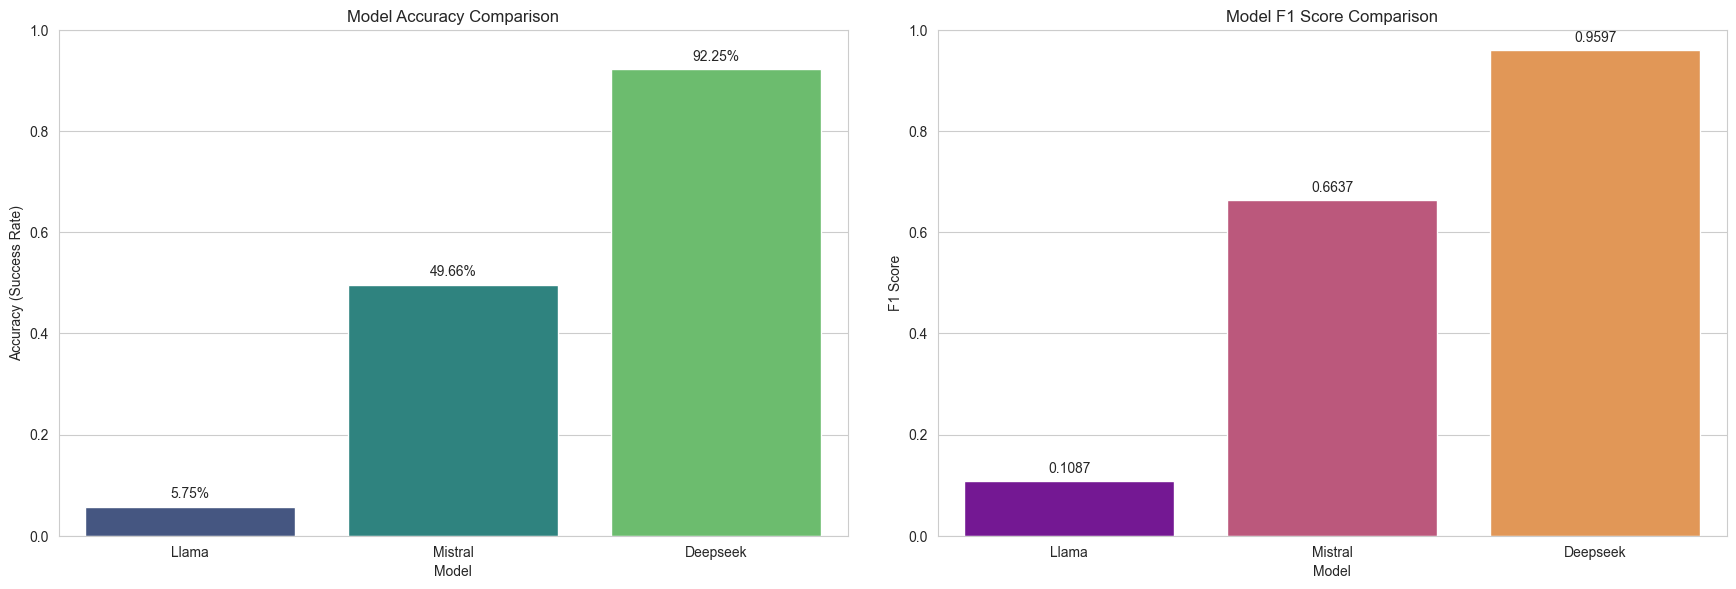

--- Results Summary ---
      Model  Valid Responses  Correct Responses  Accuracy  F1 Score  \
0     Llama              435                 25    0.0575    0.1087   
1   Mistral              443                220    0.4966    0.6637   
2  Deepseek              258                238    0.9225    0.9597   

   Evaluated Examples  Total Questions  
0                 435              500  
1                 443              500  
2                 258              500  


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Data Preparation ---
# Store the results in a dictionary
results_data = {
    'Model': ['Llama', 'Mistral', 'Deepseek'],
    'Valid Responses': [435, 443, 258],
    'Correct Responses': [25, 220, 238],
    'Accuracy': [0.0575, 0.4966, 0.9225],
    'F1 Score': [0.1087, 0.6637, 0.9597],
    'Evaluated Examples': [435, 443, 258],
    'Total Questions': [500, 500, 500]
}

# Create a Pandas DataFrame
df_results = pd.DataFrame(results_data)

# --- Visualizations ---

# Set style
sns.set_style("whitegrid")
plt.figure(figsize=(18, 12)) # Adjust figure size for better layout

# 1. Accuracy (Success Rate) Comparison
plt.subplot(2, 2, 1) # 2 rows, 2 columns, 1st plot
ax1 = sns.barplot(x='Model', y='Accuracy', data=df_results, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (Success Rate)')
plt.ylim(0, 1) # Accuracy ranges from 0 to 1
# Add percentage labels
for p in ax1.patches:
    ax1.annotate(f'{p.get_height()*100:.2f}%',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center',
                   xytext=(0, 9),
                   textcoords='offset points')

# 2. F1 Score Comparison
plt.subplot(2, 2, 2) # 2 rows, 2 columns, 2nd plot
ax2 = sns.barplot(x='Model', y='F1 Score', data=df_results, palette='plasma')
plt.title('Model F1 Score Comparison')
plt.ylabel('F1 Score')
plt.ylim(0, 1) # F1 score ranges from 0 to 1
# Add F1 score labels
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.4f}',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center',
                   xytext=(0, 9),
                   textcoords='offset points')


# Adjust layout and display plots
plt.tight_layout(pad=3.0) # Add padding between plots
plt.show()

# Optional: Display the DataFrame
print("--- Results Summary ---")
print(df_results)

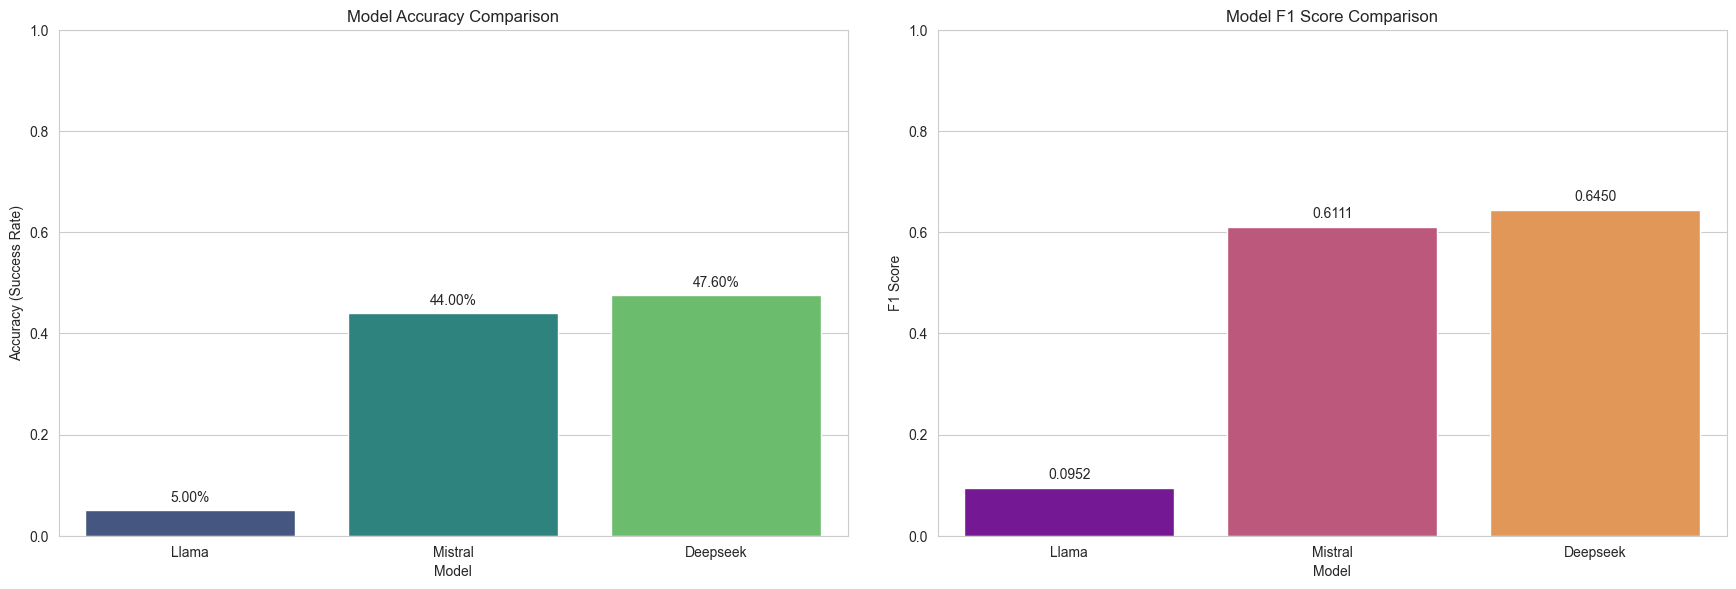

--- Results Summary ---
      Model  Valid Responses  Correct Responses  Accuracy  F1 Score  \
0     Llama              435                 25     0.050    0.0952   
1   Mistral              443                220     0.440    0.6111   
2  Deepseek              258                238     0.476    0.6450   

   Evaluated Examples  Total Questions  
0                 435              500  
1                 443              500  
2                 258              500  


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Data Preparation ---
# Store the results in a dictionary
results_data = {
    'Model': ['Llama', 'Mistral', 'Deepseek'],
    'Valid Responses': [435, 443, 258],
    'Correct Responses': [25, 220, 238],
    'Accuracy': [0.05, 0.44, 0.476],
    'F1 Score': [0.0952, 0.6111, 0.6450],
    'Evaluated Examples': [435, 443, 258],
    'Total Questions': [500, 500, 500]
}

# Create a Pandas DataFrame
df_results = pd.DataFrame(results_data)

# --- Visualizations ---

# Set style
sns.set_style("whitegrid")
plt.figure(figsize=(18, 12)) # Adjust figure size for better layout
# 1. Accuracy (Success Rate) Comparison
plt.subplot(2, 2, 1) # 2 rows, 2 columns, 1st plot
ax1 = sns.barplot(x='Model', y='Accuracy', data=df_results, palette='viridis',hue='Model')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (Success Rate)')
plt.ylim(0, 1) # Accuracy ranges from 0 to 1
# Add percentage labels
for p in ax1.patches:
    ax1.annotate(f'{p.get_height()*100:.2f}%',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center',
                   xytext=(0, 9),
                   textcoords='offset points')

# 2. F1 Score Comparison
plt.subplot(2, 2, 2) # 2 rows, 2 columns, 2nd plot
ax2 = sns.barplot(x='Model', y='F1 Score', data=df_results, palette='plasma',hue='Model')
plt.title('Model F1 Score Comparison')
plt.ylabel('F1 Score')
plt.ylim(0, 1) # F1 score ranges from 0 to 1
# Add F1 score labels
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.4f}',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center',
                   xytext=(0, 9),
                   textcoords='offset points')


# Adjust layout and display plots
plt.tight_layout(pad=3.0) # Add padding between plots
plt.show()

# Optional: Display the DataFrame
print("--- Results Summary ---")
print(df_results)

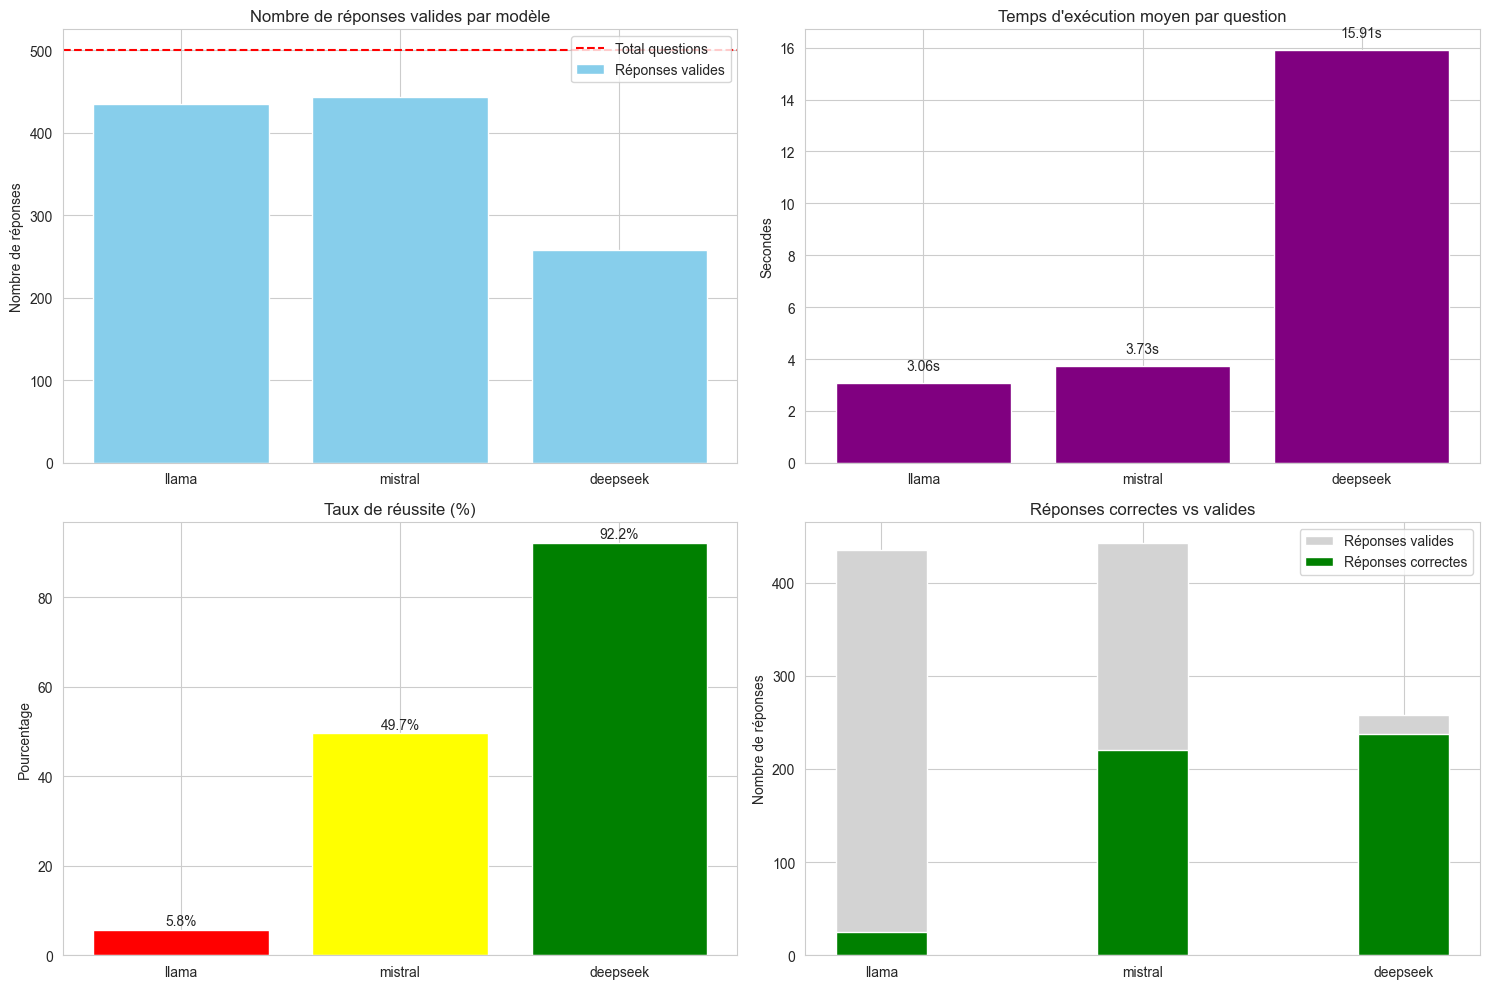

In [10]:
import matplotlib.pyplot as plt

# Data
models = ['llama', 'mistral', 'deepseek']
valid_responses = [435, 443, 258]
correct_answers = [25, 220, 238]
success_rates = [5.75, 49.66, 92.25]
temps_execution_moyenne_par_question = [3.06, 3.73, 15.91]  # in seconds

# Create figure with 4 subplots
fig, ((ax1, ax4), (ax3, ax2)) = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Valid responses vs total
ax1.bar(models, valid_responses, label='Réponses valides', color='skyblue')
ax1.axhline(y=500, color='red', linestyle='--', label='Total questions')
ax1.set_title('Nombre de réponses valides par modèle')
ax1.set_ylabel('Nombre de réponses')
ax1.legend()

# Plot 2: Correct vs valid responses
width = 0.35
ax2.bar(models, valid_responses, width, label='Réponses valides', color='lightgray')
ax2.bar(models, correct_answers, width, label='Réponses correctes', color='green')
ax2.set_title('Réponses correctes vs valides')
ax2.set_ylabel('Nombre de réponses')
ax2.legend()

# Plot 3: Success rates
ax3.bar(models, success_rates, color=['red', 'yellow', 'green'])
ax3.set_title('Taux de réussite (%)')
ax3.set_ylabel('Pourcentage')
for i, v in enumerate(success_rates):
    ax3.text(i, v + 1, f'{v:.1f}%', ha='center')

# Plot 4: Average execution time per question
ax4.bar(models, temps_execution_moyenne_par_question, color='purple')
ax4.set_title('Temps d\'exécution moyen par question')
ax4.set_ylabel('Secondes')
for i, t in enumerate(temps_execution_moyenne_par_question):
    ax4.text(i, t + 0.5, f'{t:.2f}s', ha='center')

plt.tight_layout()
plt.show()


# Raisonnement : HellaSwag

In [11]:
llama = pd.read_csv('hellaswag/llama2-7b_hellaswag.csv').dropna()
accuracy_llama_hellaswag = accuracy_score(llama['true_label'], llama['predicted_index'])
print(f"Accuracy: {accuracy_llama_hellaswag*100:.2f} %")

f1_llama_hellaswag = f1_score(llama['true_label'], llama['predicted_index'], average='weighted')
print(f"F1 Score: {f1_llama_hellaswag:.4f}")

Accuracy: 24.10 %
F1 Score: 0.1560


In [12]:
mistral = pd.read_csv('hellaswag/mistral-7b_hellaswag.csv')
accuracy_mistral_hellaswag = accuracy_score(mistral['true_label'], mistral['predicted_index'])
print(f"Accuracy: {accuracy_mistral_hellaswag*100:.2f} %")

f1_mistral_hellaswag = f1_score(mistral['true_label'], mistral['predicted_index'], average='weighted')
print(f"F1 Score: {f1_mistral_hellaswag:.4f}")

Accuracy: 61.20 %
F1 Score: 0.6111


In [13]:
deepseek = pd.read_csv('hellaswag/deepseek-r1_hellaswag.csv')
accuracy_deepseek_hellaswag = accuracy_score(deepseek['true_label'], deepseek['predicted_index'])
print(f"Accuracy: {accuracy_deepseek_hellaswag*100:.2f} %")

f1_deepseek_hellaswag = f1_score(deepseek['true_label'], deepseek['predicted_index'], average='weighted')
print(f"F1 Score: {f1_deepseek_hellaswag:.4f}")

Accuracy: 51.80 %
F1 Score: 0.5157


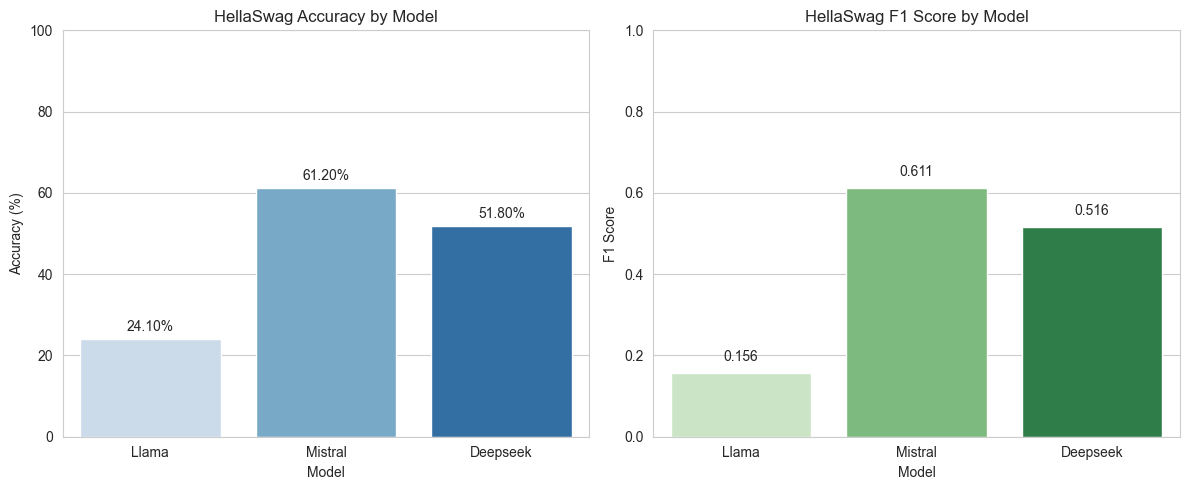

In [14]:
import seaborn as sns

import matplotlib.pyplot as plt

# Prepare data for HellaSwag benchmark
hellaswag_models = ['Llama', 'Mistral', 'Deepseek']
hellaswag_accuracy = [
    accuracy_llama_hellaswag * 100,
    accuracy_mistral_hellaswag * 100,
    accuracy_deepseek_hellaswag * 100
]
hellaswag_f1 = [
    f1_llama_hellaswag,
    f1_mistral_hellaswag,
    f1_deepseek_hellaswag
]

# Create a DataFrame for plotting
hellaswag_df = pd.DataFrame({
    'Model': hellaswag_models,
    'Accuracy (%)': hellaswag_accuracy,
    'F1 Score': hellaswag_f1
})

# Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='Accuracy (%)', data=hellaswag_df, palette='Blues',hue ='Model')
plt.title('HellaSwag Accuracy by Model')
plt.ylim(0, 100)
for i, v in enumerate(hellaswag_accuracy):
    plt.text(i, v + 2, f"{v:.2f}%", ha='center')

plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='F1 Score', data=hellaswag_df, palette='Greens',hue ='Model')
plt.title('HellaSwag F1 Score by Model')
plt.ylim(0, 1)
for i, v in enumerate(hellaswag_f1):
    plt.text(i, v + 0.03, f"{v:.3f}", ha='center')

plt.tight_layout()
plt.show()

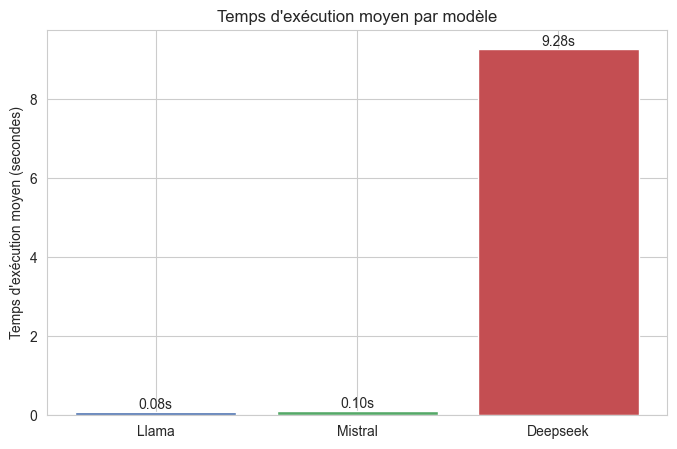

In [15]:
import matplotlib.pyplot as plt

model_names = ['Llama', 'Mistral', 'Deepseek']
execution_times = [40/500, 50/500, 9.28]  # en secondes

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, execution_times, color=['#4C72B0', '#55A868', '#C44E52'])
plt.ylabel("Temps d'exécution moyen (secondes)")
plt.title("Temps d'exécution moyen par modèle")

for bar, t in zip(bars, execution_times):
    plt.text(bar.get_x() + bar.get_width() / 2, t, f"{t:.2f}s", ha='center', va='bottom')

plt.show()

# Génération de code : HumanEval

In [16]:
mistral_human_eval = pd.read_csv("humaneval/mistral-7b_humaneval.csv")
# Alternative way to calculate accuracy
accuracy_mistral_he = mistral_human_eval["passed"].sum() / len(mistral_human_eval) * 100
print(f"Accuracy: {accuracy_mistral_he:.2f}%")
f1_mistral_he = f1_score(mistral_human_eval["passed"], [True]*len(mistral_human_eval))
print(f"F1 Score: {f1_mistral_he:.4f}")


Accuracy: 31.71%
F1 Score: 0.4815


In [17]:
llama_human_eval = pd.read_csv("humaneval/llama2-7b_humaneval.csv")
# Alternative way to calculate accuracy
accuracy_llama_he = llama_human_eval["passed"].sum() / len(llama_human_eval) * 100
print(f"Accuracy: {accuracy_llama_he:.2f}%")
f1_llama_he = f1_score(llama_human_eval["passed"], [True]*len(llama_human_eval))
print(f"F1 Score: {f1_llama_he:.4f}")


Accuracy: 9.15%
F1 Score: 0.1676


In [18]:
deepseek_human_eval = pd.read_csv("humaneval/deepseek-r1_humaneval.csv")
# Alternative way to calculate accuracy
accuracy_deepseek_he = deepseek_human_eval["passed"].sum() / len(deepseek_human_eval) * 100
print(f"Accuracy: {accuracy_deepseek_he:.2f}%")
f1_deepseek_he = f1_score(deepseek_human_eval["passed"], [True]*len(deepseek_human_eval))
print(f"F1 Score: {f1_deepseek_he:.4f}")

Accuracy: 78.05%
F1 Score: 0.8767


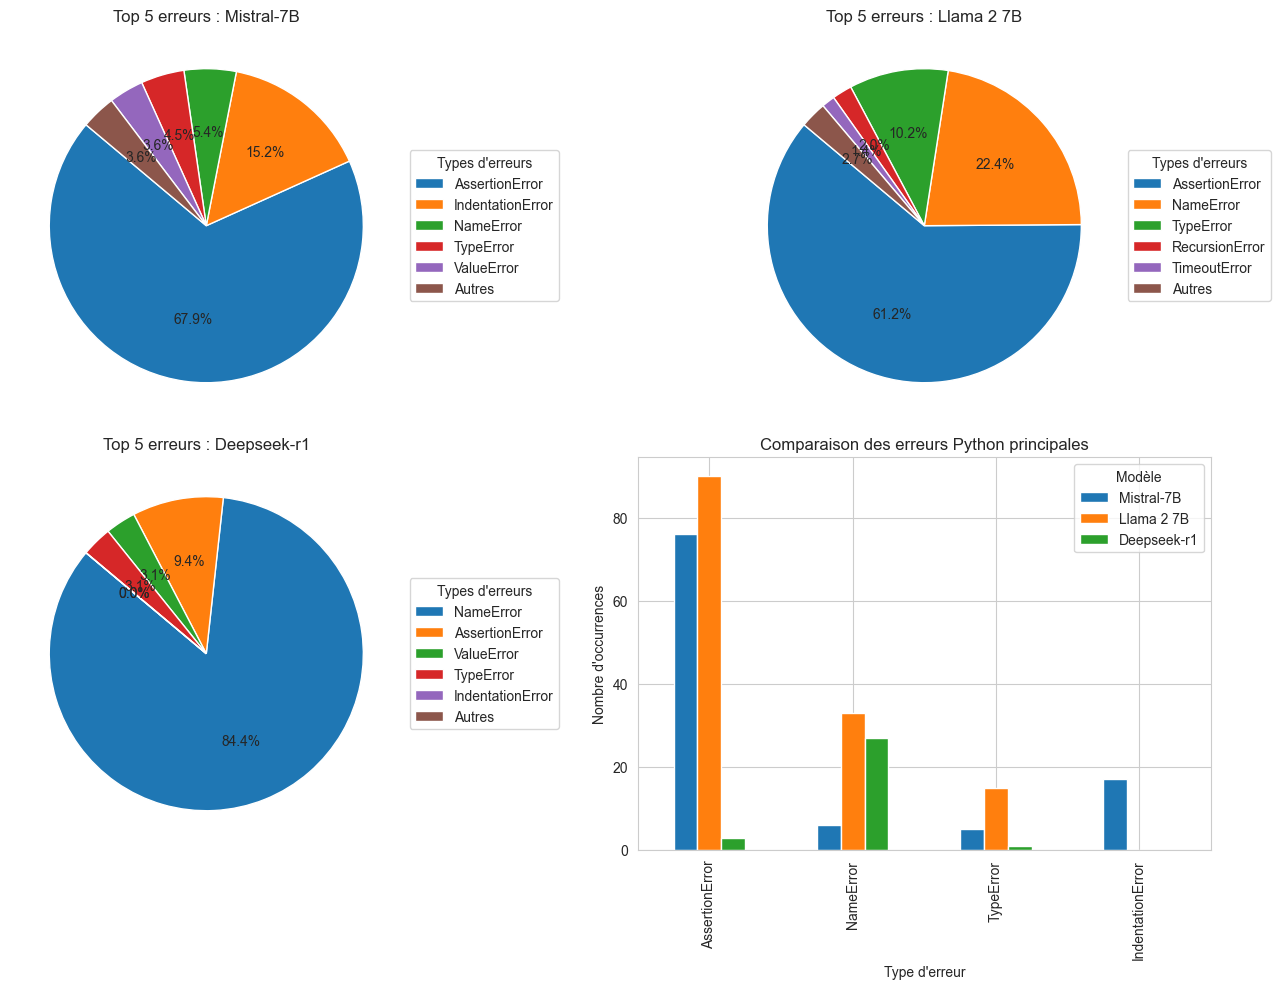

In [19]:
from collections import Counter

import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

error_types = [
    "SyntaxError",
    "IndentationError",
    "NameError",
    "TypeError",
    "AttributeError",
    "KeyError",
    "IndexError",
    "ValueError",
    "TimeoutError",
    "ModuleNotFoundError",
    "ZeroDivisionError",
    "RecursionError",
    "FileNotFoundError",
    "OSError",
    "NotImplementedError",
    "StopIteration",
    "AssertionError",
    "RuntimeError",
]

# 1. Mistral-7B
counts_mistral = {err: mistral_human_eval['error_message'].dropna().str.contains(err).sum() for err in error_types}
series_mistral = pd.Series(counts_mistral).sort_values(ascending=False)
top5_mistral = series_mistral.iloc[:5]
others_mistral = series_mistral.iloc[5:].sum()
top5_mistral['Autres'] = others_mistral
labels_mistral = top5_mistral.index.tolist()
sizes_mistral = top5_mistral.values.tolist()
axs[0, 0].pie(sizes_mistral, labels=[None]*len(labels_mistral), autopct='%1.1f%%', startangle=140)
axs[0, 0].legend(labels_mistral, title="Types d'erreurs", loc="center left", bbox_to_anchor=(1, 0.5))
axs[0, 0].set_title("Top 5 erreurs : Mistral-7B")

# 2. Llama 2 7B
counts_llama = {err: llama_human_eval['error_message'].dropna().str.contains(err).sum() for err in error_types}
series_llama = pd.Series(counts_llama).sort_values(ascending=False)
top5_llama = series_llama.iloc[:5]
others_llama = series_llama.iloc[5:].sum()
top5_llama['Autres'] = others_llama
labels_llama = top5_llama.index.tolist()
sizes_llama = top5_llama.values.tolist()
axs[0, 1].pie(sizes_llama, labels=[None]*len(labels_llama), autopct='%1.1f%%', startangle=140)
axs[0, 1].legend(labels_llama, title="Types d'erreurs", loc="center left", bbox_to_anchor=(1, 0.5))
axs[0, 1].set_title("Top 5 erreurs : Llama 2 7B")

# 3. Deepseek-r1
counts_deepseek = {err: deepseek_human_eval['error_message'].dropna().str.contains(err).sum() for err in error_types}
series_deepseek = pd.Series(counts_deepseek).sort_values(ascending=False)
top5_deepseek = series_deepseek.iloc[:5]
others_deepseek = series_deepseek.iloc[5:].sum()
top5_deepseek['Autres'] = others_deepseek
labels_deepseek = top5_deepseek.index.tolist()
sizes_deepseek = top5_deepseek.values.tolist()
axs[1, 0].pie(sizes_deepseek, labels=[None]*len(labels_deepseek), autopct='%1.1f%%', startangle=140)
axs[1, 0].legend(labels_deepseek, title="Types d'erreurs", loc="center left", bbox_to_anchor=(1, 0.5))
axs[1, 0].set_title("Top 5 erreurs : Deepseek-r1")

# 4. Comparaison des erreurs Python principales entre les trois modèles

# Sélectionner les 4 types d'erreurs les plus fréquents globalement

# Rassembler les top erreurs de chaque modèle
all_top_errors = (
    list(top5_mistral.index[:-1]) +  # enlever 'Autres'
    list(top5_llama.index[:-1]) +
    list(top5_deepseek.index[:-1])
)
most_common_errors = [err for err, _ in Counter(all_top_errors).most_common(4)]

# Construire un DataFrame pour la comparaison
error_counts = {
    "Mistral-7B": [series_mistral.get(err, 0) for err in most_common_errors],
    "Llama 2 7B": [series_llama.get(err, 0) for err in most_common_errors],
    "Deepseek-r1": [series_deepseek.get(err, 0) for err in most_common_errors],
}
df_errors = pd.DataFrame(error_counts, index=most_common_errors)

# Barplot groupé
df_errors.plot(kind='bar', ax=axs[1, 1], color=['tab:blue', 'tab:orange', 'tab:green'])
axs[1, 1].set_title("Comparaison des erreurs Python principales")
axs[1, 1].set_ylabel("Nombre d'occurrences")
axs[1, 1].set_xlabel("Type d'erreur")
axs[1, 1].legend(title="Modèle")

plt.tight_layout()
plt.show()


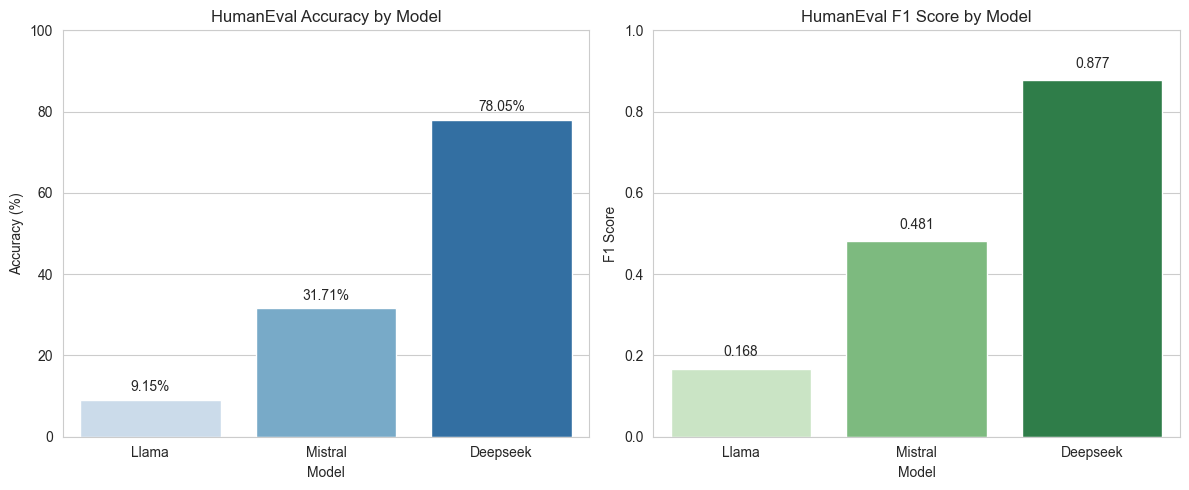

In [20]:
# Prepare data for HumanEval benchmark
humaneval_models = ['Llama', 'Mistral', 'Deepseek']
humaneval_accuracy = [
    accuracy_llama_he,
    accuracy_mistral_he,
    accuracy_deepseek_he
]
humaneval_f1 = [
    f1_llama_he,
    f1_mistral_he,
    f1_deepseek_he
]

# Create a DataFrame for plotting
humaneval_df = pd.DataFrame({
    'Model': humaneval_models,
    'Accuracy (%)': humaneval_accuracy,
    'F1 Score': humaneval_f1
})

# Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='Accuracy (%)', data=humaneval_df, palette='Blues', hue='Model')
plt.title('HumanEval Accuracy by Model')
plt.ylim(0, 100)
for i, v in enumerate(humaneval_accuracy):
    plt.text(i, v + 2, f"{v:.2f}%", ha='center')

plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='F1 Score', data=humaneval_df, palette='Greens', hue='Model')
plt.title('HumanEval F1 Score by Model')
plt.ylim(0, 1)
for i, v in enumerate(humaneval_f1):
    plt.text(i, v + 0.03, f"{v:.3f}", ha='center')

plt.tight_layout()
plt.show()


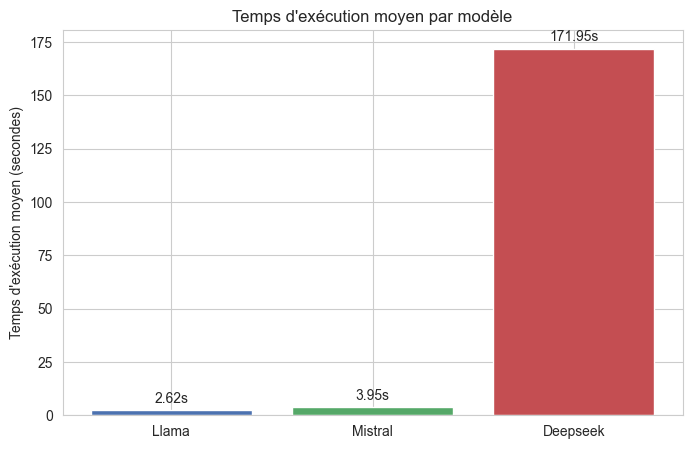

In [21]:
import matplotlib.pyplot as plt

model_names = ['Llama', 'Mistral', 'Deepseek']
execution_times = [2.62, 3.95, 171.95]  # en secondes

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, execution_times, color=['#4C72B0', '#55A868', '#C44E52'])
plt.ylabel("Temps d'exécution moyen (secondes)")
plt.title("Temps d'exécution moyen par modèle")

for bar, t in zip(bars, execution_times):
    plt.text(bar.get_x() + bar.get_width() / 2, t + 2, f"{t:.2f}s", ha='center', va='bottom')

plt.show()